# Homework 9 - Multi-Asset Allocation

This note book contains the solutions to all of "Exercise - Multi-Asset Allocation - Section 1-6"

This problem uses weekly data from data/asset_class_etf_data.xlsx.
- tab excess returns: weekly returns net of cash (SHV)
- tab descriptions: what each ticker holds

One fund per asset class, built across the course:
- equities: SPY, VEA
- bonds and credit: IEF, HYG
- commodities: GLD, USO
- crypto: BTC

BTC is the spot bitcoin series. It became investable in ETF form in late 2021 (BITO, futures-based) and via spot ETFs (IBIT, FBTC) in January 2024. The out-of-sample window below starts in 2022: the ETF era.

Annualize weekly stats with a factor of 52.

## 1 The Asset Menu
For each asset, calculate over the full sample the annualized
- Mean
- Volatility
- Sharpe ratio

In [1]:
import pandas as pd
import numpy as np

def annualized_mean (df, ticker): 
  mean_returns = df[ticker].mean()
  a_mean = mean_returns * 52
  return a_mean

def annualized_volatility(df, ticker): 
  std_returns = df[ticker].std(ddof = 1)
  a_volatility = std_returns * np.sqrt(52)
  return a_volatility

def sharpe_ratio(df_excess_return, df_total_return, ticker): 
  s_ratio = (df_excess_return[ticker].mean() / df_total_return[ticker].std(ddof=1)) * np.sqrt(52);
  return s_ratio



df_total_returns = pd.read_excel("asset_class_etf_data.xlsx", sheet_name="total returns")
df_total_returns = df_total_returns.drop(columns=['Date'])

df_excess_returns = pd.read_excel("asset_class_etf_data.xlsx", sheet_name="excess returns")
df_excess_returns = df_excess_returns.drop(columns=['Date'])

print("SPY:\n annualized_mean - ", annualized_mean(df_total_returns, "SPY"), "\n annualized_volatility - ", annualized_volatility(df_total_returns, "SPY"), "\n sharpe_ratio - ", sharpe_ratio(df_excess_returns, df_total_returns, "SPY"), "\n")
print("VEA:\n annualized_mean - ", annualized_mean(df_total_returns, "VEA"), "\n annualized_volatility - ", annualized_volatility(df_total_returns, "VEA"), "\n sharpe_ratio - ", sharpe_ratio(df_excess_returns, df_total_returns, "VEA"), "\n")
print("IEF:\n annualized_mean - ", annualized_mean(df_total_returns, "IEF"), "\n annualized_volatility - ", annualized_volatility(df_total_returns, "IEF"), "\n sharpe_ratio - ", sharpe_ratio(df_excess_returns, df_total_returns, "IEF"), "\n")
print("HYG:\n annualized_mean - ", annualized_mean(df_total_returns, "HYG"), "\n annualized_volatility - ", annualized_volatility(df_total_returns, "HYG"), "\n sharpe_ratio - ", sharpe_ratio(df_excess_returns, df_total_returns, "HYG"), "\n")
print("GLD:\n annualized_mean - ", annualized_mean(df_total_returns, "GLD"), "\n annualized_volatility - ", annualized_volatility(df_total_returns, "GLD"), "\n sharpe_ratio - ", sharpe_ratio(df_excess_returns, df_total_returns, "GLD"), "\n")
print("USO:\n annualized_mean - ", annualized_mean(df_total_returns, "USO"), "\n annualized_volatility - ", annualized_volatility(df_total_returns, "USO"), "\n sharpe_ratio - ", sharpe_ratio(df_excess_returns, df_total_returns, "USO"), "\n")
print("BTC:\n annualized_mean - ", annualized_mean(df_total_returns, "BTC"), "\n annualized_volatility - ", annualized_volatility(df_total_returns, "BTC"), "\n sharpe_ratio - ", sharpe_ratio(df_excess_returns, df_total_returns, "BTC"), "\n")


SPY:
 annualized_mean -  0.13823247486145326 
 annualized_volatility -  0.1746626940672844 
 sharpe_ratio -  0.7913222657203202 

VEA:
 annualized_mean -  0.08199554203998786 
 annualized_volatility -  0.17324385634995335 
 sharpe_ratio -  0.4731916485342963 

IEF:
 annualized_mean -  -0.008569126952486805 
 annualized_volatility -  0.06364119096623266 
 sharpe_ratio -  -0.13493026886246756 

HYG:
 annualized_mean -  -0.004676908311382553 
 annualized_volatility -  0.09655301310958084 
 sharpe_ratio -  -0.04862514607771774 

GLD:
 annualized_mean -  0.13865109225596522 
 annualized_volatility -  0.15140545283968518 
 sharpe_ratio -  0.9156413695842347 

USO:
 annualized_mean -  0.09917610046037753 
 annualized_volatility -  0.40998826282917056 
 sharpe_ratio -  0.24185595880431082 

BTC:
 annualized_mean -  0.6758980715043674 
 annualized_volatility -  0.6879309139827137 
 sharpe_ratio -  0.9824824872836524 



## 1.2
Report the correlation matrix.

Which asset offers the most diversification against SPY?

<Axes: >

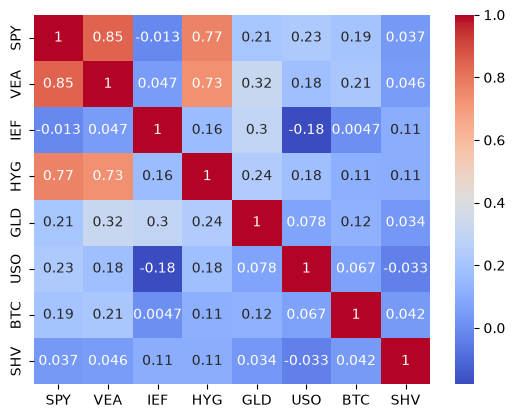

In [2]:
import seaborn as sns
sns.heatmap(df_total_returns.corr(), annot=True, cmap='coolwarm')

IEF has the lowest (and negative) correlation with SPY, which means it is loosely inversely correlated with SPY. If SPY goes down, IEF might hold steady or even go up. That cushions the blow if spy drops, making IEF a good hedge against SPY. 

## 1.3
Report each asset’s empirical VaR (.05) of weekly returns.

Which assets carry the most tail risk?

In [3]:
def empirical_var(df, ticker):
  var = -df[ticker].quantile(0.05)
  return var

print("SPY: ", empirical_var(df_total_returns, "SPY"))
print("VEA: ", empirical_var(df_total_returns, "VEA"))
print("IEF: ", empirical_var(df_total_returns, "IEF"))
print("HYG: ", empirical_var(df_total_returns, "HYG"))
print("GLD: ", empirical_var(df_total_returns, "GLD"))
print("USO: ", empirical_var(df_total_returns, "USO"))
print("BTC: ", empirical_var(df_total_returns, "BTC"))

SPY:  0.03270396981437451
VEA:  0.034911411833638946
IEF:  0.015835464062696588
HYG:  0.015587243367099877
GLD:  0.03107031686400875
USO:  0.08207364280166214
BTC:  0.1370613425093992


# 2 Simple Rules
Two portfolios that require no optimization:

- equally-weighted across the 7 assets, rebalanced weekly
- 60/40: 60% SPY, 40% IEF, rebalanced weekly

## 2.1

For each, report the annualized mean, volatility, and Sharpe over the full sample.

In [4]:
tickers = ["SPY", "VEA", "IEF", "HYG", "GLD", "USO", "BTC"]

df_EW_portfolio = df_total_returns.assign(EW_Portfolio=lambda df: df[tickers].mean(axis=1))
df_EW_portfolio_ex = df_excess_returns.assign(EW_Portfolio=lambda df: df[tickers].mean(axis=1))

df_60_40_portfolio = df_total_returns.assign(Portfolio_6040=lambda df: (df["SPY"] * 0.6 + df["IEF"] * 0.4))
df_60_40_portfolio_ex = df_excess_returns.assign(Portfolio_6040=lambda df: (df["SPY"] * 0.6 + df["IEF"] * 0.4))

print("Equally Weighted Portfolio: \n annualized_mean - ", annualized_mean(df_EW_portfolio, "EW_Portfolio"), 
      "\n annualized_volatility - ", annualized_volatility(df_EW_portfolio, "EW_Portfolio"), 
      "\n sharpe_ratio - ", sharpe_ratio(df_EW_portfolio_ex, df_EW_portfolio, "EW_Portfolio"))

print("60/40 Portfolio: \n annualized_mean - ", annualized_mean(df_60_40_portfolio, "Portfolio_6040"), 
      "\n annualized_volatility - ", annualized_volatility(df_60_40_portfolio, "Portfolio_6040"), 
      "\n sharpe_ratio - ", sharpe_ratio(df_60_40_portfolio_ex, df_60_40_portfolio, "Portfolio_6040"))


Equally Weighted Portfolio: 
 annualized_mean -  0.16010103512261167 
 annualized_volatility -  0.15176586895588684 
 sharpe_ratio -  1.0548026388846874
60/40 Portfolio: 
 annualized_mean -  0.07951183413587722 
 annualized_volatility -  0.10752955086356489 
 sharpe_ratio -  0.739274343119182


# 2.2
Report each portfolio’s empirical VaR (.05). Compare to the individual assets in 1.3.

In [5]:
print("Equally Weighted Portfolio: ", empirical_var(df_EW_portfolio, "EW_Portfolio"))
print("60/40 Porflio: ", empirical_var(df_60_40_portfolio, "Portfolio_6040"))

Equally Weighted Portfolio:  0.02859424172942276
60/40 Porflio:  0.021377834055685094


# 3 Mean-Variance Optimization
Estimate using data through 2021 only. (2022 onward is held out for Section 5.)

Exclude BTC for this section: the menu is the 6 traditional assets.

## 3.1
Calculate the tangency portfolio weights.

$$ \mathbf{w}^{\tan} = \frac{\Sigma^{-1}\mu}{\mathbf{1}'\Sigma^{-1}\mu} $$

In [6]:

df_total_returns_2021 = df_total_returns.iloc[:261].copy()
df_excess_returns_2021 = df_excess_returns.iloc[:261].copy()

tickers_no_BTC = ["SPY", "VEA", "IEF", "HYG", "GLD", "USO"]

covariance_matrix = df_total_returns_2021[tickers_no_BTC].cov()  
covariance_inverse = np.linalg.inv(covariance_matrix.values)
mean_excess = df_excess_returns_2021[tickers_no_BTC].mean()
ones = np.ones(len(tickers_no_BTC))

tangency_weights = (covariance_inverse @ mean_excess) / (ones @ covariance_inverse @ mean_excess)

print(tangency_weights)

[ 2.64419992 -1.06677868  1.09372084 -2.20895353  0.59496124 -0.05714979]


## 3.2
Do the weights look like a portfolio you could hold? Note any extreme or short positions.

Probably not. There are both extreme and short positions. For instance I would hav eto hold SPY at 2.64x and IEF at 1.09x leverage which is quite risky. On the other hand I'd have to short HYG with 2.2x leverage with is also risky. 

## 3.3
Report the in-sample (through 2021) annualized mean, volatility, and Sharpe of the tangency portfolio, alongside the equal-weight and 60/40 portfolios over the same window.

In [7]:
df_tangency_portfolio = df_total_returns_2021.assign(Portfolio_t=lambda df: (df[tickers_no_BTC].dot(tangency_weights)))
df_tangency_portfolio_ex = df_excess_returns_2021.assign(Portfolio_t=lambda df: (df[tickers_no_BTC].dot(tangency_weights)))

df_EW_portfolio_2021 = df_EW_portfolio.iloc[:261].copy()
df_EW_portfolio_ex_2021 = df_EW_portfolio_ex.iloc[:261].copy()

df_60_40_portfolio_2021 = df_60_40_portfolio.iloc[:261].copy()
df_60_40_portfolio_ex_2021 = df_60_40_portfolio_ex.iloc[:261].copy()

print("Tangency Portfolio: \n annualized_mean", annualized_mean(df_tangency_portfolio, "Portfolio_t"), 
      "\n annualized_volatility", annualized_volatility(df_tangency_portfolio, "Portfolio_t"), 
      "\n sharpe_ratio", sharpe_ratio(df_tangency_portfolio_ex, df_tangency_portfolio, "Portfolio_t"))

print("Equally Weighted Portfolio: \n annualized_mean - ", annualized_mean(df_EW_portfolio_2021, "EW_Portfolio"), 
      "\n annualized_volatility - ", annualized_volatility(df_EW_portfolio_2021, "EW_Portfolio"), 
      "\n sharpe_ratio - ", sharpe_ratio(df_EW_portfolio_ex_2021, df_EW_portfolio_2021, "EW_Portfolio"))

print("60/40 Portfolio: \n annualized_mean - ", annualized_mean(df_60_40_portfolio_2021, "Portfolio_6040"), 
      "\n annualized_volatility - ", annualized_volatility(df_60_40_portfolio_2021, "Portfolio_6040"), 
      "\n sharpe_ratio - ", sharpe_ratio(df_60_40_portfolio_ex_2021, df_60_40_portfolio_2021, "Portfolio_6040"))

Tangency Portfolio: 
 annualized_mean 0.40345543989473137 
 annualized_volatility 0.2297416942172537 
 sharpe_ratio 1.755624693343034
Equally Weighted Portfolio: 
 annualized_mean -  0.20511941210861312 
 annualized_volatility -  0.17228083343488798 
 sharpe_ratio -  1.1899417920429112
60/40 Portfolio: 
 annualized_mean -  0.10209233507305174 
 annualized_volatility -  0.10576769714930788 
 sharpe_ratio -  0.9641609809528016


## 4 A New Asset Class
Now add BTC to the menu. Still estimating through 2021 only.

## 4.1
Recalculate the tangency weights with all 7 assets.

How large is the BTC allocation?

In [8]:
covariance_matrix_with_BTC = df_total_returns_2021[tickers].cov()  
covariance_inverse_with_BTC = np.linalg.inv(covariance_matrix_with_BTC.values)
mean_excess_with_BTC = df_excess_returns_2021[tickers].mean()
ones_with_BTC = np.ones(len(tickers))

tangency_weights_with_BTC = (covariance_inverse_with_BTC @ mean_excess_with_BTC) / (ones_with_BTC @ covariance_inverse_with_BTC @ mean_excess_with_BTC)

print(tangency_weights_with_BTC)

[ 2.79147567 -1.49250341  1.0334621  -1.93006774  0.45957125 -0.0725742
  0.21063634]


## 4.2

Using BTC’s through-2021 mean, volatility, and correlations, explain why the optimizer sizes it the way it does.

BTC is weighted smaller than the others (aside from gold). While BTC had massive excess returns, it was also incredibly volatile. So despite having the best Sharpe ratio, it didn't get a large portion of the portfolio. 

## 4.3

Would you take this allocation to an investment committee? What would you have to believe about the future mean of BTC for it to be justified?

I would not. In 2021, this means that I believe BTC will remain volatile, but in the long run go upwards. The way things were at the time, BTC was too volatile to realistically hold. 

# 5 Out of Sample
Hold the weights estimated through 2021 fixed. Evaluate on 2022 through mid-2026: the ETF era.

## 5.1
For four portfolios,

- tangency (ex-BTC)
- tangency (with BTC)
- equal-weight
- 60/40

report the out-of-sample annualized mean, volatility, and Sharpe.

In [9]:
df_total_returns_2022o = df_total_returns.iloc[261:].copy()
df_excess_returns_2022o = df_excess_returns.iloc[261:].copy()

#############################

covariance_matrix_2022o = df_total_returns_2022o[tickers_no_BTC].cov()  
covariance_inverse_2022o = np.linalg.inv(covariance_matrix_2022o.values)
mean_excess_2022o = df_excess_returns_2022o[tickers_no_BTC].mean()
ones_2022o = np.ones(len(tickers_no_BTC))

tangency_weights_2022o = (covariance_inverse_2022o @ mean_excess_2022o) / (ones_2022o @ covariance_inverse_2022o @ mean_excess_2022o)

df_tangency_portfolio_2022o = df_total_returns_2022o.assign(Portfolio_t=lambda df: (df[tickers_no_BTC].dot(tangency_weights)))
df_tangency_portfolio_ex_2022o = df_excess_returns_2022o.assign(Portfolio_t=lambda df: (df[tickers_no_BTC].dot(tangency_weights)))

#############################

covariance_matrix_with_BTC_2022o = df_total_returns_2022o[tickers].cov()  
covariance_inverse_with_BTC_2022o = np.linalg.inv(covariance_matrix_with_BTC_2022o.values)
mean_excess_with_BTC_2022o = df_excess_returns_2022o[tickers].mean()
ones_with_BTC_2022o = np.ones(len(tickers))

tangency_weights_with_BTC_2022o = (covariance_inverse_with_BTC_2022o @ mean_excess_with_BTC_2022o) / (ones_with_BTC_2022o @ covariance_inverse_with_BTC_2022o @ mean_excess_with_BTC_2022o)

df_tangency_portfolio_with_BTC_2022o = df_total_returns_2022o.assign(Portfolio_t=lambda df: (df[tickers].dot(tangency_weights_with_BTC_2022o)))
df_tangency_portfolio_with_BTC_ex_2022o = df_excess_returns_2022o.assign(Portfolio_t=lambda df: (df[tickers].dot(tangency_weights_with_BTC_2022o)))

############################

df_EW_portfolio_2022o = df_EW_portfolio.iloc[261:].copy()
df_EW_portfolio_ex_2022o = df_EW_portfolio_ex.iloc[261:].copy()

df_60_40_portfolio_2022o = df_60_40_portfolio.iloc[261:].copy()
df_60_40_portfolio_ex_2022o = df_60_40_portfolio_ex.iloc[261:].copy()

#############################

print("Tangency Portfolio without BTC: \n annualized_mean", annualized_mean(df_tangency_portfolio_2022o, "Portfolio_t"), 
      "\n annualized_volatility", annualized_volatility(df_tangency_portfolio_2022o, "Portfolio_t"), 
      "\n sharpe_ratio", sharpe_ratio(df_tangency_portfolio_ex_2022o, df_tangency_portfolio_2022o, "Portfolio_t"))

print("Tangency Portfolio with BTC: \n annualized_mean", annualized_mean(df_tangency_portfolio_with_BTC_2022o, "Portfolio_t"), 
      "\n annualized_volatility", annualized_volatility(df_tangency_portfolio_with_BTC_2022o, "Portfolio_t"), 
      "\n sharpe_ratio", sharpe_ratio(df_tangency_portfolio_with_BTC_ex_2022o, df_tangency_portfolio_with_BTC_2022o, "Portfolio_t"))

print("Equally Weighted Portfolio: \n annualized_mean - ", annualized_mean(df_EW_portfolio_2022o, "EW_Portfolio"), 
      "\n annualized_volatility - ", annualized_volatility(df_EW_portfolio_2022o, "EW_Portfolio"), 
      "\n sharpe_ratio - ", sharpe_ratio(df_EW_portfolio_ex_2022o, df_EW_portfolio_2022o, "EW_Portfolio"))

print("60/40 Portfolio: \n annualized_mean - ", annualized_mean(df_60_40_portfolio_2022o, "Portfolio_6040"), 
      "\n annualized_volatility - ", annualized_volatility(df_60_40_portfolio_2022o, "Portfolio_6040"), 
      "\n sharpe_ratio - ", sharpe_ratio(df_60_40_portfolio_ex_2022o, df_60_40_portfolio_2022o, "Portfolio_6040"))

Tangency Portfolio without BTC: 
 annualized_mean 0.30247322492743267 
 annualized_volatility 0.26698747147803475 
 sharpe_ratio 1.1332523079068018
Tangency Portfolio with BTC: 
 annualized_mean -0.5421748283944732 
 annualized_volatility 0.3148484582250536 
 sharpe_ratio -1.7217295207453103
Equally Weighted Portfolio: 
 annualized_mean -  0.1096727244215543 
 annualized_volatility -  0.12485619629050596 
 sharpe_ratio -  0.8791207083821151
60/40 Portfolio: 
 annualized_mean -  0.054217796605394226 
 annualized_volatility -  0.1095910989783474 
 sharpe_ratio -  0.4955579460278615


## 5.2
Compare the in-sample and out-of-sample rankings. Which portfolio would you actually have wanted to hold?

In-sample: the ranking of sharpe ratios was: tangency (1.76) > equal-weight (1.19) > 60/40 (0.96)

Out-of-sample: the ranking was tangency ex-BTC (1.13) > equal-weight (0.88) > 60/40 (0.50) > tangency with BTC (-1.72). 

The equal-weight portfolio is the one I would have wanted to hold. It didn't have the best sharpe ratio, but it was never disastrous either, and it doesn't depend on getting the mean-variance inputs right. The 6-asset tangency portfolio also did fine both in and out of sample. Unsurprisingly the one with BTC failed badly since the asset's estimated mean was unreliable.


## 5.3
Does the out-of-sample result vindicate or indict the optimizer? Careful: one out-of-sample window is itself a small sample.

Indict. The with-BTC tangency portfolio's catastrophic performance shows the central weakness of the method in practice: it doesn't just weight assets by their  risk-return tradeoff, but by how precisely that tradeoff has been estimated. BTC had the shortest, most volatile history among the seven assets, and the optimizer treated its estimated mean as if it were known with the same confidence as SPY. 

# 6 Fragility
## 6.1
Re-estimate the tangency weights (all 7 assets) on rolling 3-year (156-week) windows. Plot the weights through time.

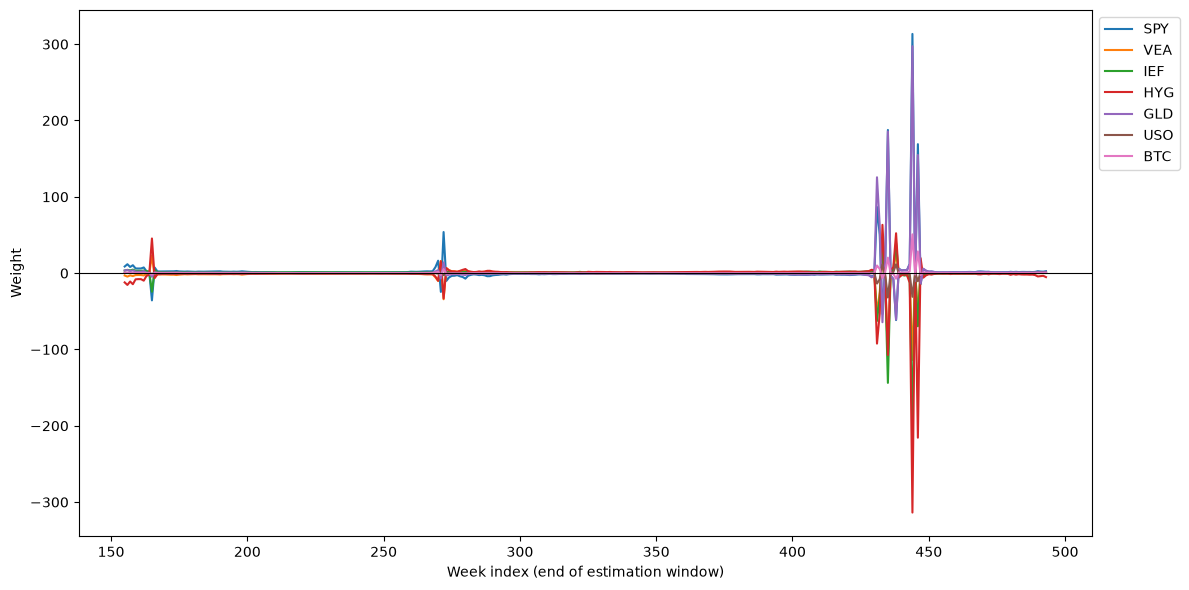

In [10]:
import plt

rolling_dates = []
rolling_weights = []

for end in range(156, len(df_total_returns) + 1):
  window = df_total_returns[tickers].iloc[end - 156:end]
  window_ex = df_excess_returns[tickers].iloc[end - 156:end]

  window_covariance_matrix = window.cov()
  window_covariance_inverse = np.linalg.inv(window_covariance_matrix.values)
  window_mean_excess = window_ex.mean().values
  window_ones = np.ones(len(tickers))

  w = (window_covariance_inverse @ window_mean_excess) / (window_ones @ window_covariance_inverse @ window_mean_excess)

  rolling_weights.append(w)
  rolling_dates.append(end - 1) 

df_rolling_weights = pd.DataFrame(rolling_weights, columns=tickers, index=rolling_dates)

df_rolling_weights.plot(figsize=(12, 6))
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Week index (end of estimation window)")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()


## 6.2
Estimate the tangency weights on two subsamples: 2017-2019 and 2020-2021. Report both sets side by side.

     2017-2019  2020-2021
SPY  11.670831   3.930338
VEA  -4.576934  -2.354758
IEF   4.252897   1.255041
HYG -15.470494  -2.028143
GLD   4.169529  -0.034225
USO   0.316053  -0.154980
BTC   0.638118   0.386727


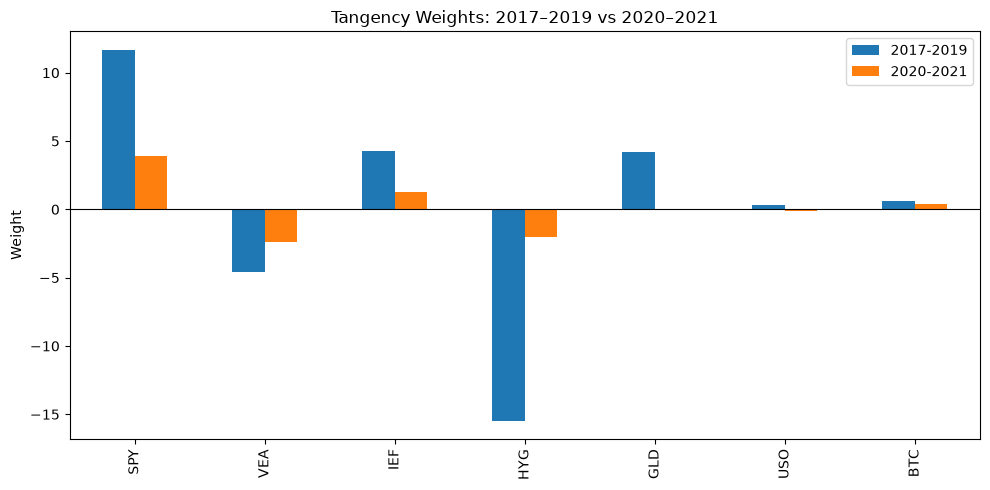

In [11]:
import matplotlib.pyplot as plt

#1-156 2017-2019

df1719 = df_total_returns[tickers].iloc[1 : 157]
df1719_ex = df_excess_returns[tickers].iloc[1 : 157]

df1719_covariance_matrix = df1719.cov()
df1719_covariance_inverse = np.linalg.inv(df1719_covariance_matrix.values)
df1719_mean_excess = df1719_ex.mean().values
df1719_ones = np.ones(len(tickers))

df1719_weights = (df1719_covariance_inverse @ df1719_mean_excess) / (df1719_ones @ df1719_covariance_inverse @ df1719_mean_excess)

#157-261 2020-2021

df2021 = df_total_returns[tickers].iloc[157 : 262]
df2021_ex = df_excess_returns[tickers].iloc[157 : 262]

df2021_covariance_matrix = df2021.cov()
df2021_covariance_inverse = np.linalg.inv(df2021_covariance_matrix.values)
df2021_mean_excess = df2021_ex.mean().values
df2021_ones = np.ones(len(tickers))

df2021_weights = (df2021_covariance_inverse @ df2021_mean_excess) / (df2021_ones @ df2021_covariance_inverse @ df2021_mean_excess)

#####################

weights_1719 = pd.Series(df1719_weights, index=tickers, name="2017-2019")
weights_2021 = pd.Series(df2021_weights, index=tickers, name="2020-2021")

comparison = pd.concat([weights_1719, weights_2021], axis=1)
print(comparison)

comparison.plot(kind="bar", figsize=(10, 5))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Tangency Weights: 2017–2019 vs 2020–2021")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


## 6.3
The math of mean-variance is exact; the inputs are estimates.

Which input is the bigger problem: the means or the covariance matrix?

Given 6.1 and 6.2, why do practitioners constrain weights, shrink estimates, or fall back to simple rules?

THe means are the bigger problems. Expected returns are hard to calculate while covariance matrix is a lot more easy to be precise with. 

Given 6.1 and 6.2, practitioners:
- constrain weights to prevent extreme long/short position which is caused by estimation errors in the mean
- shrink estimates to prevent the estimation error at the source
- fall back to simple rules (e.g. ew or 6040) to just avoid the problems associated with estimation errors entirely. 

Sections 6.1 and 6.2 show exactly why practitioners don't use raw tangency weights in practice:
